# Pipeline de Minería de Reglas de Asociación
**Minería de Datos II – BD162 | Colegio Universitario de Cartago**  
**Grupo #3:** Pablo Marín Castillo · Alejandro Quesada Leiva

## 0. Configuración de entorno

In [1]:
%matplotlib inline
import sys
import os

# Agrega la raíz del proyecto al path (igual que app.py)
ROOT = os.path.abspath('')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import pandas as pd
from src.utils.path import obtener_ruta_app
from src.processed.Pipeline import Pipeline

print(f'Raíz del proyecto: {ROOT}')
print('Imports OK')

Raíz del proyecto: C:\Users\pmari\OneDrive\Para Revisar\Documentos\GitKraken\ReglasAsociacion\notebooks
Imports OK ✅


---
## 1. Carga del CSV

Carga el archivo igual que lo hace `CargaDatos` antes de llamar a `Pipeline`.

In [2]:
# ── LAPTOPS ──────────────────────────────────────────────────────────
base_dir  = obtener_ruta_app()
ruta_csv  = os.path.join(base_dir, 'data', 'raw', 'dataset_laptops.csv')

df_laptops = pd.read_csv(ruta_csv, delimiter=',', decimal='.')

print(f'Dataset cargado: {ruta_csv}')
print(f'Dimensiones    : {df_laptops.shape}')
df_laptops.head()

Dataset cargado: C:\Users\pmari\OneDrive\Para Revisar\Documentos\GitKraken\ReglasAsociacion\data\raw\dataset_laptops.csv
Dimensiones    : (984, 98)


,Unnamed: 0,link,name,user rating,Price,Sales Package,Model Number,Part Number,Model Name,Series,...,Security Chip,Inbuilt 4G LTE,Cloud Storage,S-video,Dock Port,Firewire Port,RJ11,Read/Write Speed,EMMC Storage Capacity,Optane Memory
0,0,https://www.flipkart.com/asus-rog-strix-scar-1...,ASUS ROG Strix SCAR 17 Core i9 12th Gen - (32 ...,5.0,"?2,34,990","Laptop, Power Adaptor, User Guide, Warranty Do...",G733ZW-LL139WS,90NR08G2-M007S0,G733ZW-LL139WS,ROG Strix SCAR 17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,https://www.flipkart.com/asus-rog-strix-scar-1...,ASUS ROG Strix SCAR 15 Core i9 12th Gen - (32 ...,NaN,"?2,29,990","Laptop, Power Adaptor, User Guide, Warranty Do...",G533ZW-LN136WS,90NR0872-M007L0,G533ZW-LN136WS,ROG Strix SCAR 15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,https://www.flipkart.com/hp-victus-ryzen-7-oct...,HP Victus Ryzen 7 Octa Core 5800H - (16 GB/512...,NaN,"?1,04,091","Laptop, battery, adapter, cables and user manuals",16-e0351AX,552X1PA#ACJ,16-e0351AX,Victus,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,https://www.flipkart.com/lenovo-ideapad-gaming...,Lenovo IdeaPad Gaming 3i Ryzen 7 Octa Core R7-...,NaN,"?87,717","Laptop, Power Adaptor, User Guide, Warranty Do...",15ACH6,82K201RSIN,IdeaPad Gaming 3,IdeaPad Gaming 3i,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,https://www.flipkart.com/lenovo-yoga-slim-7-co...,Lenovo Yoga Slim 7 Core i5 11th Gen - (16 GB/5...,NaN,"?75,990","Laptop, Adaptor",82A300MBIN,1LS2B001653,Yoga Slim 7 14ITL05,Yoga Slim 7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# ── TURISMO ──────────────────────────────────────────────────────────
ruta_csv_t = os.path.join(base_dir, 'data', 'raw', 'tourism.csv')

df_tourism = pd.read_csv(ruta_csv_t, delimiter=',', decimal='.')

print(f'Dataset cargado: {ruta_csv_t}')
print(f'Dimensiones    : {df_tourism.shape}')
df_tourism.head()

Dataset cargado: C:\Users\pmari\OneDrive\Para Revisar\Documentos\GitKraken\ReglasAsociacion\data\raw\tourism.csv
Dimensiones    : (5000, 14)


,Tourist ID,Age,Interests,Preferred Tour Duration,Accessibility,Site Name,Sites Visited,Tour Duration,Route ID,Tourist Rating,System Response Time,Recommendation Accuracy,VR Experience Quality,Satisfaction
0,1,48,"['Architecture', 'Art', 'History']",5,False,Eiffel Tower,"['Eiffel Tower', 'Great Wall of China', 'Taj M...",7,1000,1.6,3.73,97,4.5,3
1,2,37,"['Cultural', 'Nature']",6,False,Colosseum,['Great Wall of China'],1,2000,2.6,2.89,90,4.5,3
2,3,43,"['History', 'Art', 'Architecture']",6,True,Machu Picchu,['Eiffel Tower'],2,3000,1.7,2.22,94,4.7,3
3,4,46,"['Cultural', 'Art', 'Architecture']",8,False,Colosseum,"['Machu Picchu', 'Taj Mahal']",5,4000,2.0,2.34,92,4.7,3
4,5,53,"['Architecture', 'Art']",5,True,Colosseum,"['Machu Picchu', 'Taj Mahal', 'Great Wall of C...",7,5000,3.7,2.00,96,4.8,4


---
## 2. Parámetros del modelo

Los mismos valores que expone `CargaDatos` en los sliders.

In [4]:
MIN_SUPPORT    = 0.3   # soporte mínimo
MIN_CONFIDENCE = 0.5   # confianza mínima

print(f'Soporte mínimo    : {MIN_SUPPORT}')
print(f'Confianza mínima  : {MIN_CONFIDENCE}')

Soporte mínimo    : 0.3
Confianza mínima  : 0.5


---
## 3. Pipeline — Laptops

Reproduce exactamente la llamada que hace `CargaDatos` cuando detecta `'laptops'` en el nombre del archivo.


  PIPELINE DE MINERÍA DE REGLAS DE ASOCIACIÓN

▶▶▶ PASO 1: CARGA Y LIMPIEZA ◀◀◀
             Dimensiones: 984 filas x 98 columnas
[DataLoader] Columnas seleccionadas: ['name', 'Sales Package', 'Color', 'Type', 'Suitable For', 'Processor Brand', 'Processor Name', 'RAM', 'RAM Type', 'Operating System']
[DataLoader] Duplicados eliminados: 40
[DataLoader] Dimensiones limpias: 944 filas x 10 columnas

▶▶▶ PASO 2: ANÁLISIS EXPLORATORIO (EDA) ◀◀◀

RESUMEN DEL DATASET
  Filas    : 944
  Columnas : 10
  Tipos de datos:
name                object
Sales Package       object
Color               object
Type                object
Suitable For        object
Processor Brand     object
Processor Name      object
RAM                 object
RAM Type            object
Operating System    object

  Duplicados: 0 (0.0%)
  Nulos totales: 0

--- ESTADÍSTICAS CATEGÓRICAS ---

  name (top 5):
name
Lenovo IdeaPad 3 Core i3 10th Gen - (8 GB/256 GB SSD/Windows 10 Home) 15IIL05 Laptop  (15.6 inch, Platinum Grey, 1

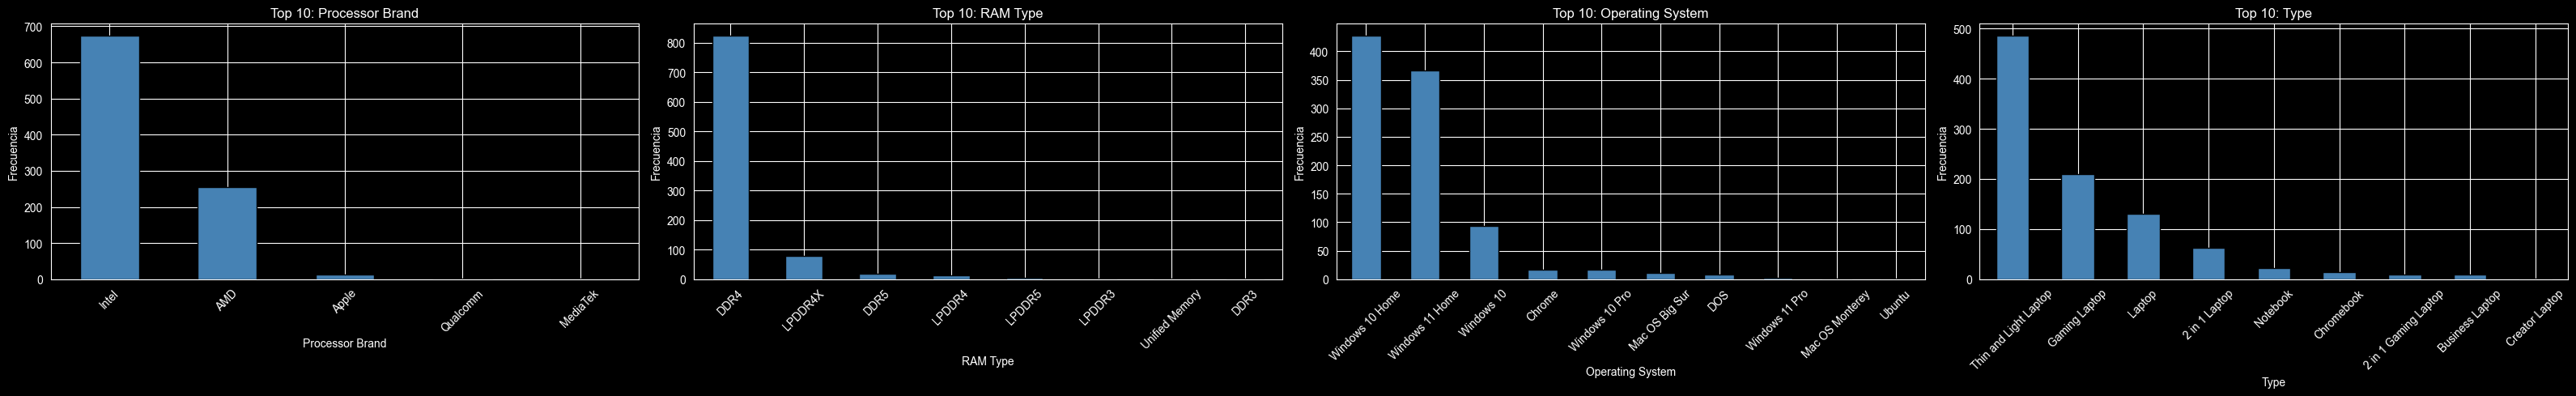


▶▶▶ PASO 3: TRANSFORMACIÓN ◀◀◀
[Transformer] Columna 'Sales Package' convertida a listas.
[Transformer] Columna combinada 'items_combined' creada desde: ['Color', 'Type', 'Suitable For', 'Processor Brand', 'Processor Name', 'RAM', 'RAM Type', 'Operating System']
[Transformer] Columna 'items_combined' convertida a listas.

▶▶▶ PASO 4: MODELOS DE ASOCIACIÓN ◀◀◀

  ── Columna: 'Sales Package' (944 transacciones) ──

[Apriori] Ejecutando con soporte=0.3, confianza=0.5 ...
[Apriori] Itemsets frecuentes: 15
[Apriori] Reglas generadas  : 50

--- TOP 10 REGLAS APRIORI ---
                             antecedents                              consequents  support  confidence     lift
             (Power Adaptor, User Guide)             (Laptop, Warranty Documents) 0.480932    0.854991 1.633828
            (Laptop, Warranty Documents)              (Power Adaptor, User Guide) 0.480932    0.919028 1.633828
                         (Power Adaptor)             (Laptop, Warranty Documents) 0.480932  

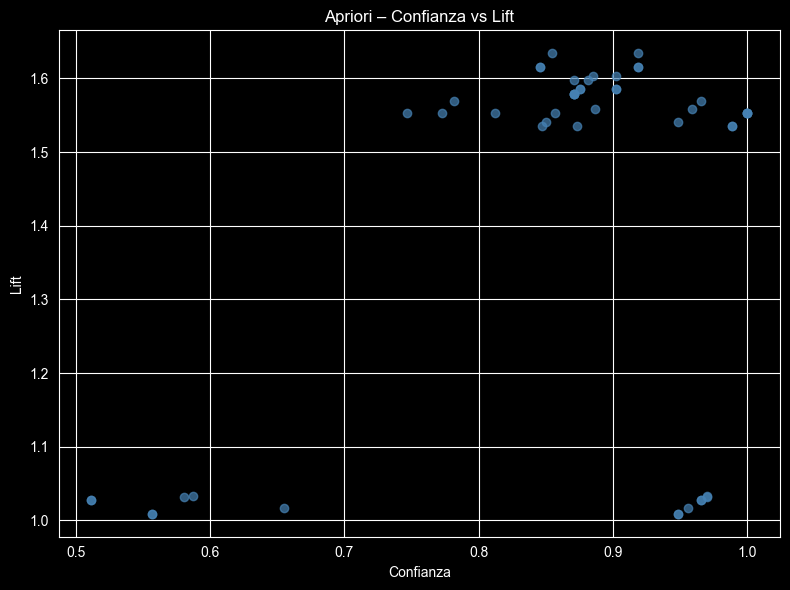

[Apriori] Gráfica guardada: outputs/laptops\Sales_Package\apriori\network_rules.png


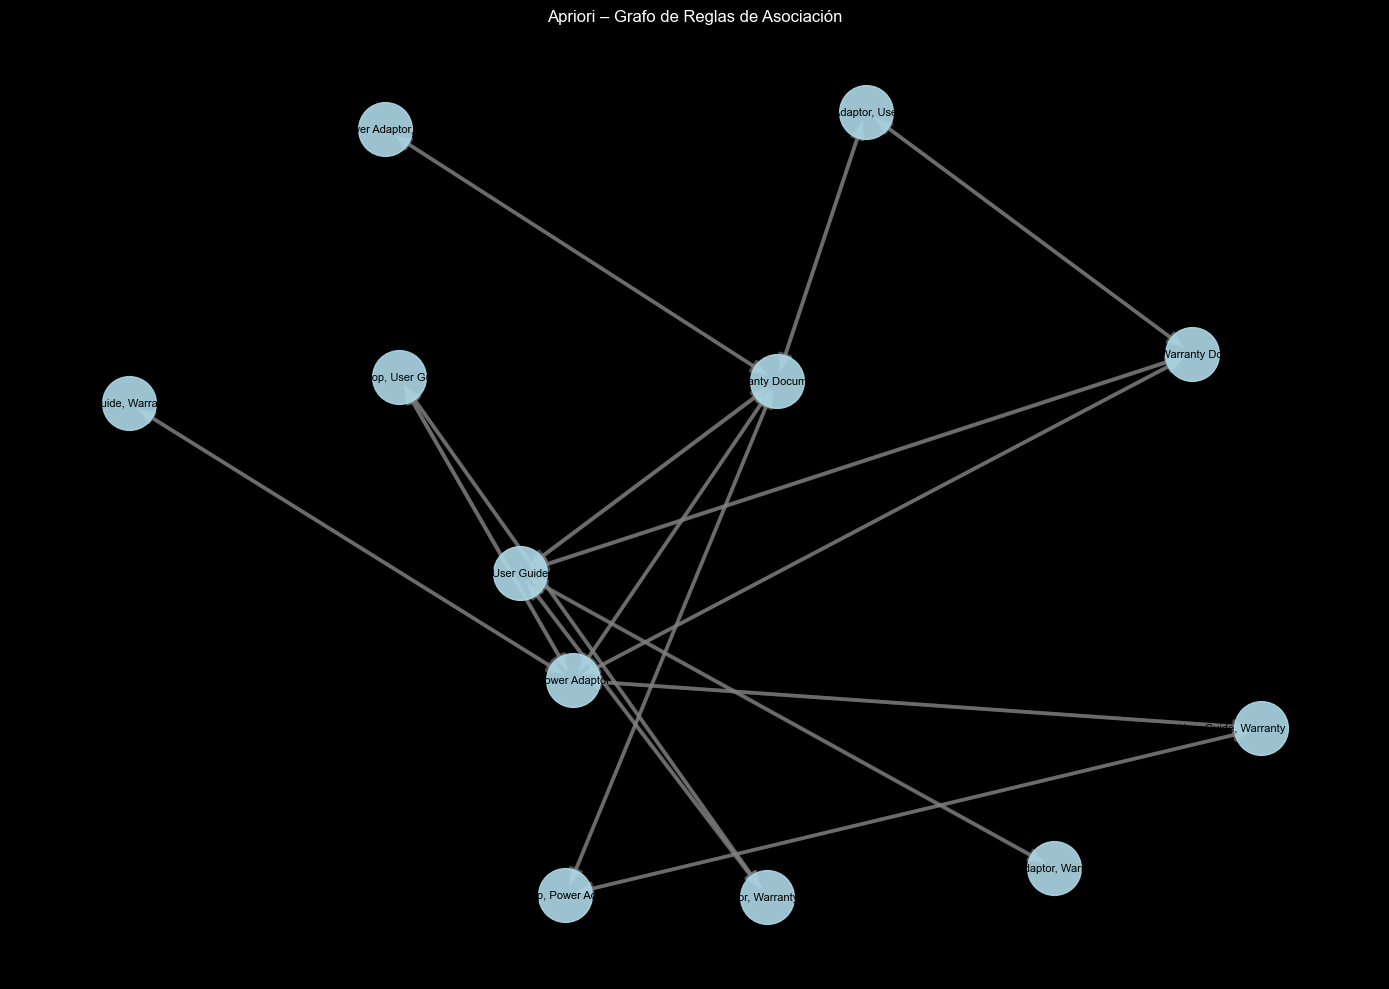


[ECLAT] Ejecutando con soporte=0.3, confianza=0.5 ...
[ECLAT] Itemsets frecuentes: 15
[ECLAT] Reglas generadas  : 50

--- TOP 10 REGLAS ECLAT ---
                             antecedents                              consequents  support  confidence   lift
             (Power Adaptor, User Guide)             (Laptop, Warranty Documents)   0.4809      0.8550 1.6338
            (Laptop, Warranty Documents)              (Power Adaptor, User Guide)   0.4809      0.9190 1.6338
                         (Power Adaptor) (Laptop, User Guide, Warranty Documents)   0.4809      0.8454 1.6156
            (Laptop, Warranty Documents)                          (Power Adaptor)   0.4809      0.9190 1.6156
                         (Power Adaptor)             (Laptop, Warranty Documents)   0.4809      0.8454 1.6156
(Laptop, User Guide, Warranty Documents)                          (Power Adaptor)   0.4809      0.9190 1.6156
             (Power Adaptor, User Guide)                     (Warranty Documents)  

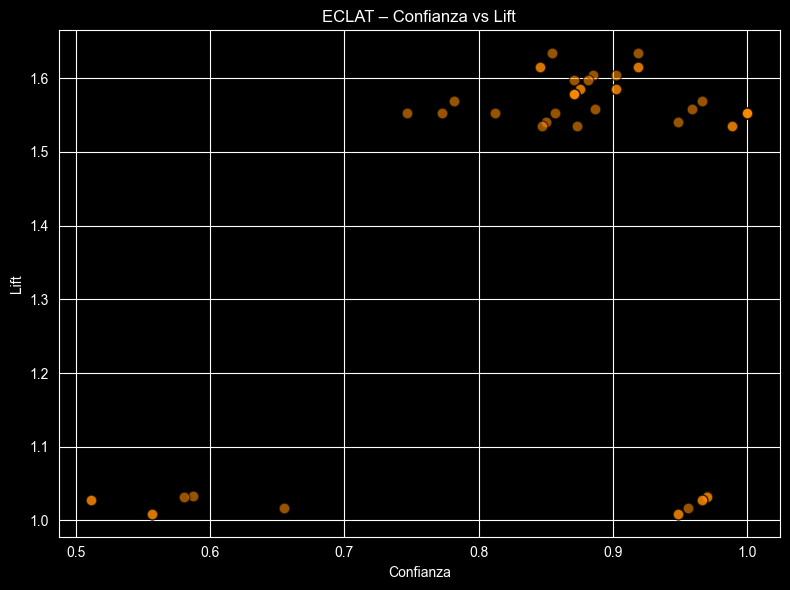

[ECLAT] Gráfica guardada: outputs/laptops\Sales_Package\eclat\network_rules.png


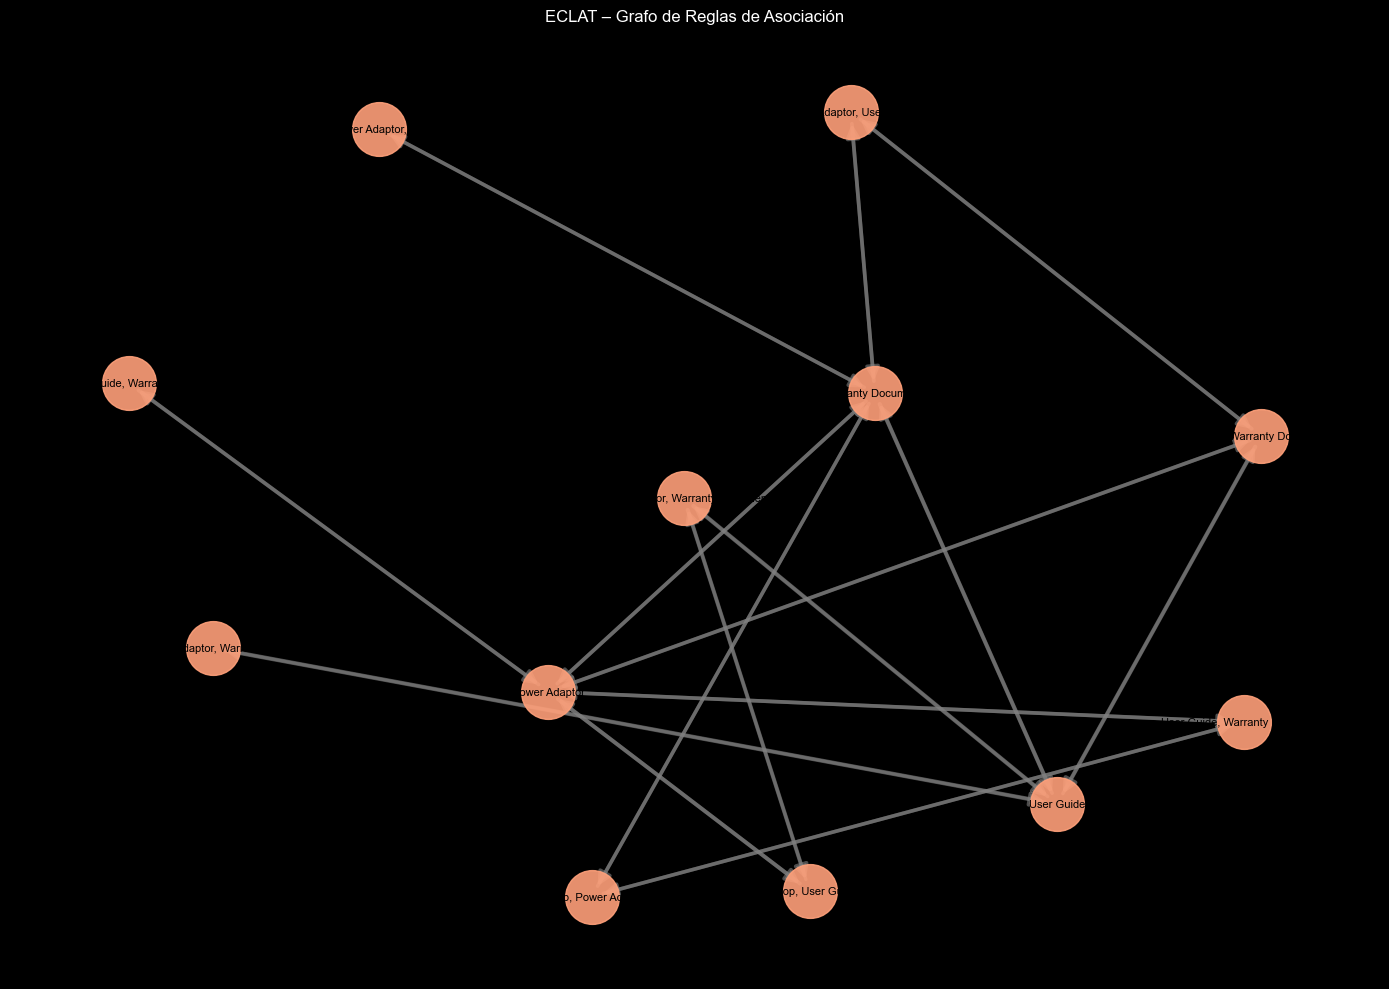


  ── Columna: 'items_combined' (944 transacciones) ──

[Apriori] Ejecutando con soporte=0.3, confianza=0.5 ...
[Apriori] Itemsets frecuentes: 34
[Apriori] Reglas generadas  : 75

--- TOP 10 REGLAS APRIORI ---
                       antecedents                        consequents  support  confidence     lift
                         (Core i5)                            (Intel) 0.307203    1.000000 1.402675
                            (8 GB)      (Thin and Light Laptop, DDR4) 0.315678    0.551852 1.237407
     (Thin and Light Laptop, DDR4)                             (8 GB) 0.315678    0.707838 1.237407
(Processing & Multitasking, Intel)            (Thin and Light Laptop) 0.347458    0.608534 1.184446
           (Thin and Light Laptop) (Processing & Multitasking, Intel) 0.347458    0.676289 1.184446
       (Processing & Multitasking)            (Thin and Light Laptop) 0.466102    0.592194 1.152641
           (Thin and Light Laptop)        (Processing & Multitasking) 0.466102    0.907216

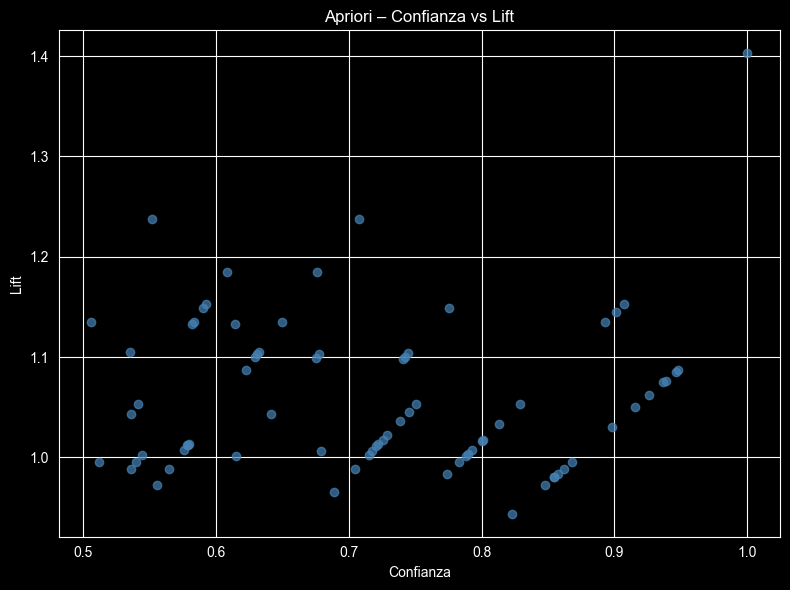

[Apriori] Gráfica guardada: outputs/laptops\items_combined\apriori\network_rules.png


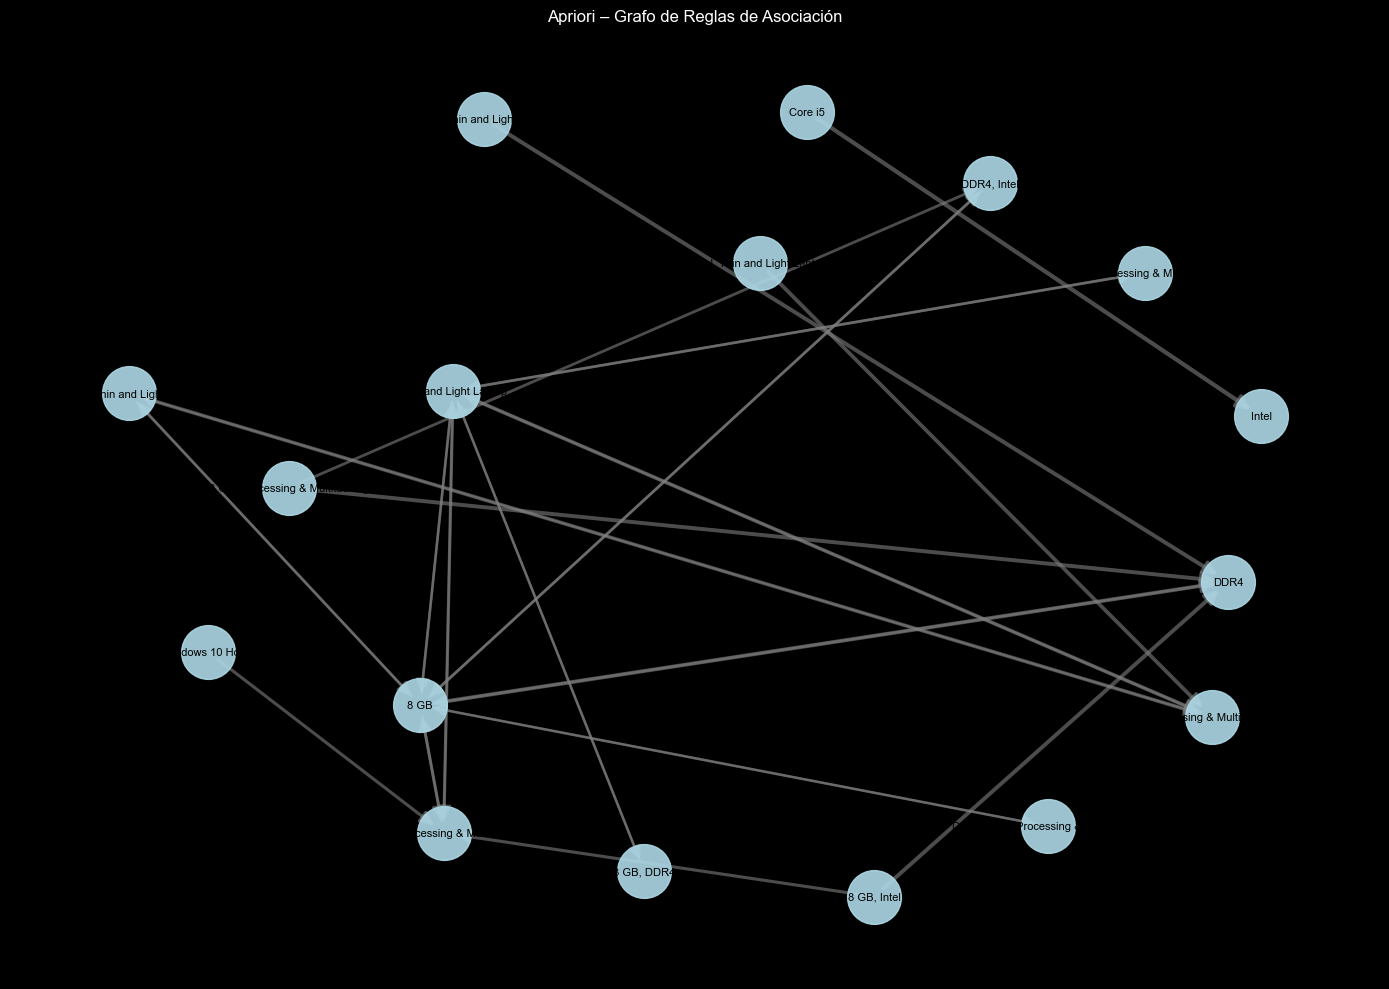


[ECLAT] Ejecutando con soporte=0.3, confianza=0.5 ...
[ECLAT] Itemsets frecuentes: 34
[ECLAT] Reglas generadas  : 75

--- TOP 10 REGLAS ECLAT ---
                       antecedents                        consequents  support  confidence   lift
                         (Core i5)                            (Intel)   0.3072      1.0000 1.4027
     (Thin and Light Laptop, DDR4)                             (8 GB)   0.3157      0.7078 1.2374
                            (8 GB)      (Thin and Light Laptop, DDR4)   0.3157      0.5519 1.2374
           (Thin and Light Laptop) (Processing & Multitasking, Intel)   0.3475      0.6763 1.1844
(Processing & Multitasking, Intel)            (Thin and Light Laptop)   0.3475      0.6085 1.1844
       (Processing & Multitasking)            (Thin and Light Laptop)   0.4661      0.5922 1.1526
           (Thin and Light Laptop)        (Processing & Multitasking)   0.4661      0.9072 1.1526
           (Thin and Light Laptop)  (Processing & Multitasking, DDR4)

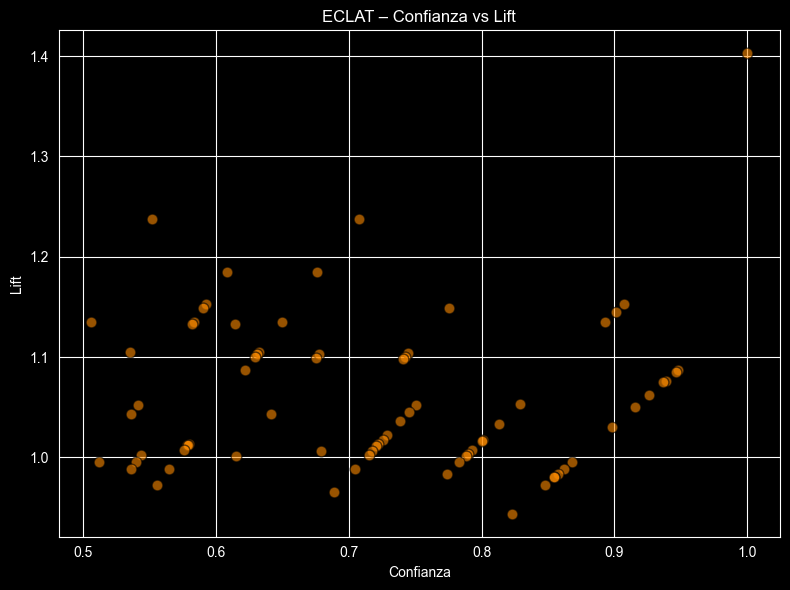

[ECLAT] Gráfica guardada: outputs/laptops\items_combined\eclat\network_rules.png


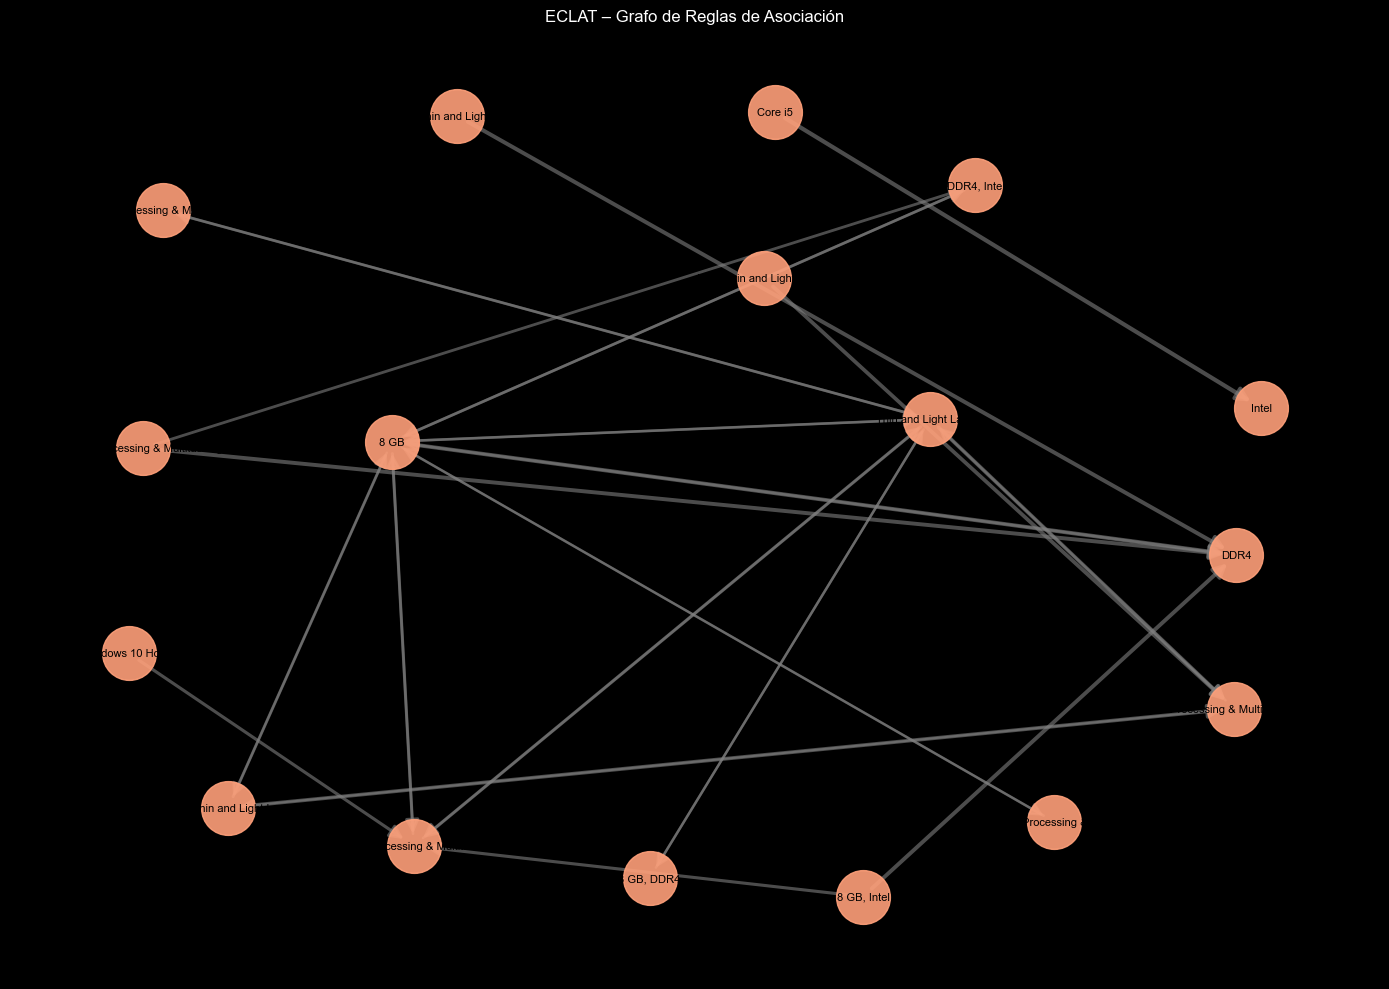


▶▶▶ PASO 5: EXPORTACIÓN DE RESULTADOS ◀◀◀
[Pipeline] Reglas exportadas: outputs/laptops\Sales_Package\rules_apriori.csv
[Pipeline] Reglas exportadas: outputs/laptops\Sales_Package\rules_eclat.csv
[Pipeline] Reglas exportadas: outputs/laptops\items_combined\rules_apriori.csv
[Pipeline] Reglas exportadas: outputs/laptops\items_combined\rules_eclat.csv

  PIPELINE FINALIZADO ✓

Output dir : outputs/laptops
Columnas procesadas: ['Sales Package', 'items_combined']


In [5]:
pp_laptops = Pipeline(
    df=df_laptops,
    min_support=MIN_SUPPORT,
    min_confidence=MIN_CONFIDENCE,
)

results_laptops, output_dir_laptops = pp_laptops.execute('laptops')

print(f'\nOutput dir : {output_dir_laptops}')
print(f'Columnas procesadas: {list(results_laptops.keys())}')

---
## 3. Pipeline — Turismo

Reproduce exactamente la llamada que hace `CargaDatos` cuando detecta `'tourism'` en el nombre del archivo.

Soporte mínimo    : 0.1
Confianza mínima  : 0.1

  PIPELINE DE MINERÍA DE REGLAS DE ASOCIACIÓN

▶▶▶ PASO 1: CARGA Y LIMPIEZA ◀◀◀
             Dimensiones: 5000 filas x 14 columnas
[DataLoader] Columnas seleccionadas: ['Tourist ID', 'Age', 'Interests', 'Sites Visited', 'Preferred Tour Duration', 'Tour Duration']
[DataLoader] Duplicados eliminados: 0
[DataLoader] Dimensiones limpias: 5000 filas x 6 columnas

▶▶▶ PASO 2: ANÁLISIS EXPLORATORIO (EDA) ◀◀◀

RESUMEN DEL DATASET
  Filas    : 5000
  Columnas : 6
  Tipos de datos:
Tourist ID                  int64
Age                         int64
Interests                  object
Sites Visited              object
Preferred Tour Duration     int64
Tour Duration               int64

  Duplicados: 0 (0.0%)
  Nulos totales: 0

--- ESTADÍSTICAS NUMÉRICAS ---
                          count       mean          std   min      25%     50%      75%     max
Tourist ID               5000.0  2500.5000  1443.520003   1.0  1250.75  2500.5  3750.25  5000.0
Age

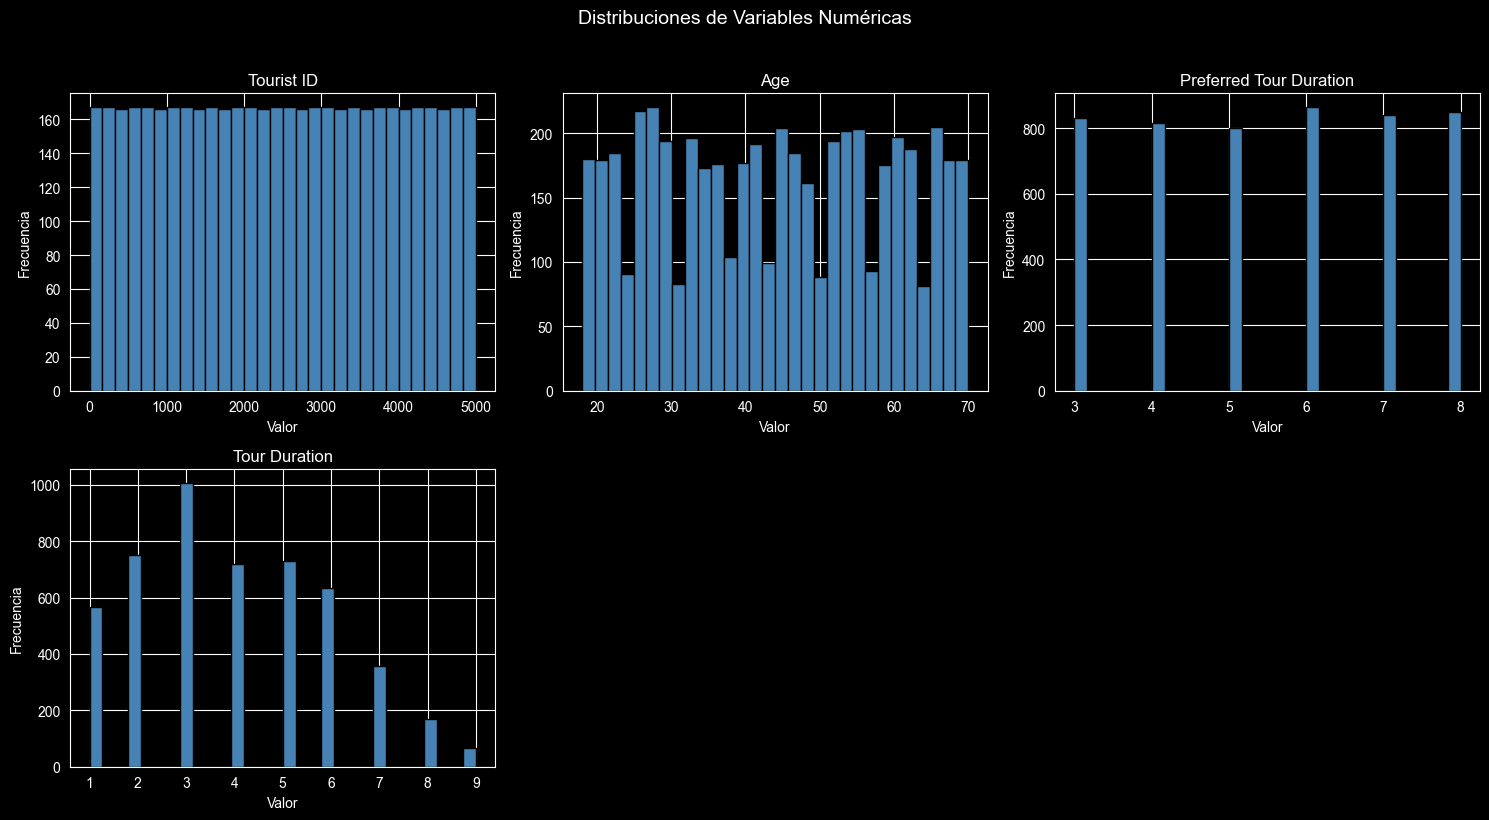

[EDA] Gráfica guardada: outputs/tourism\eda\boxplots.png


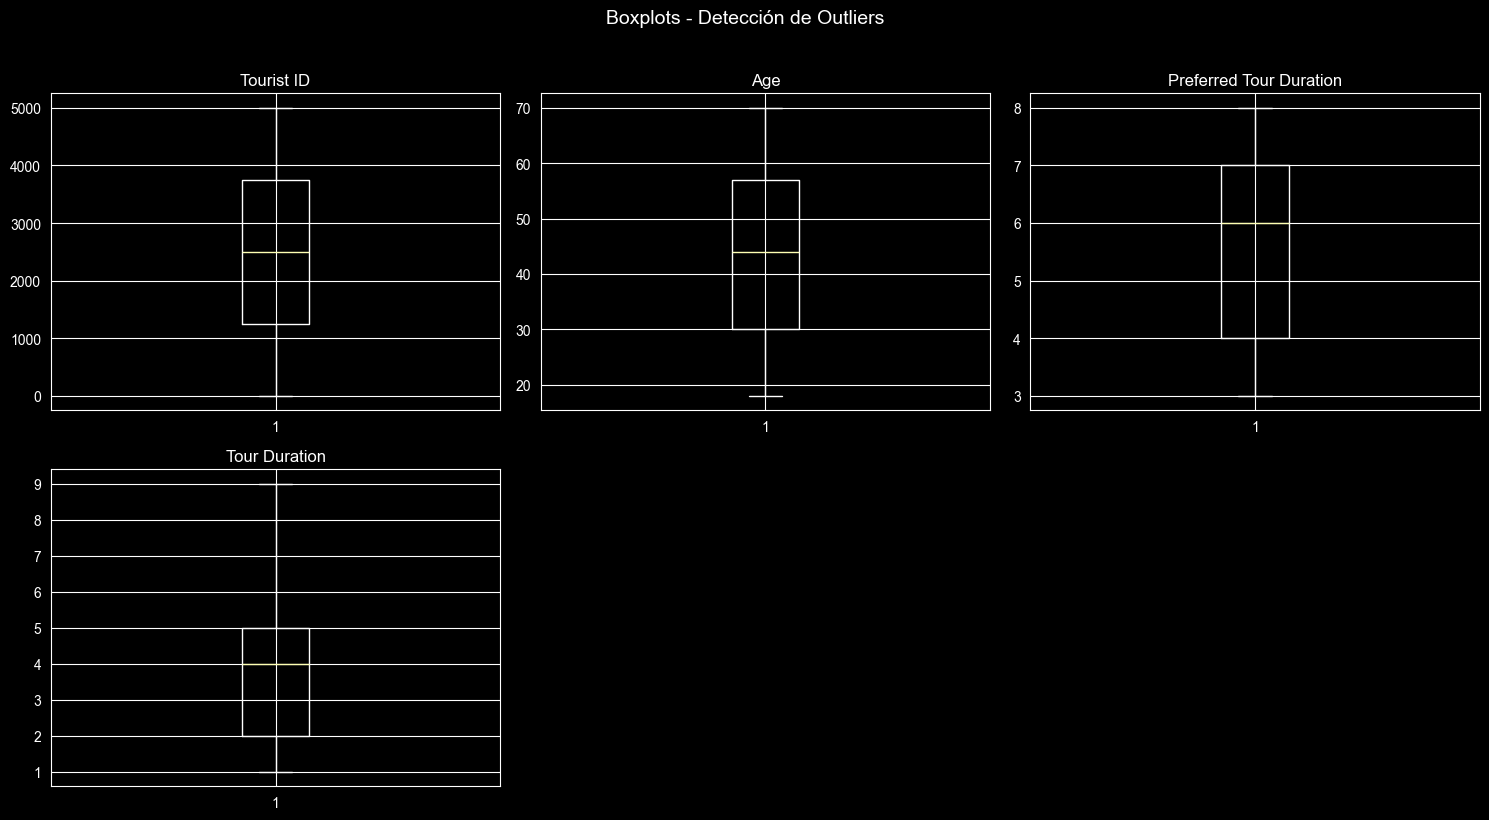

[EDA] Gráfica guardada: outputs/tourism\eda\correlation.png


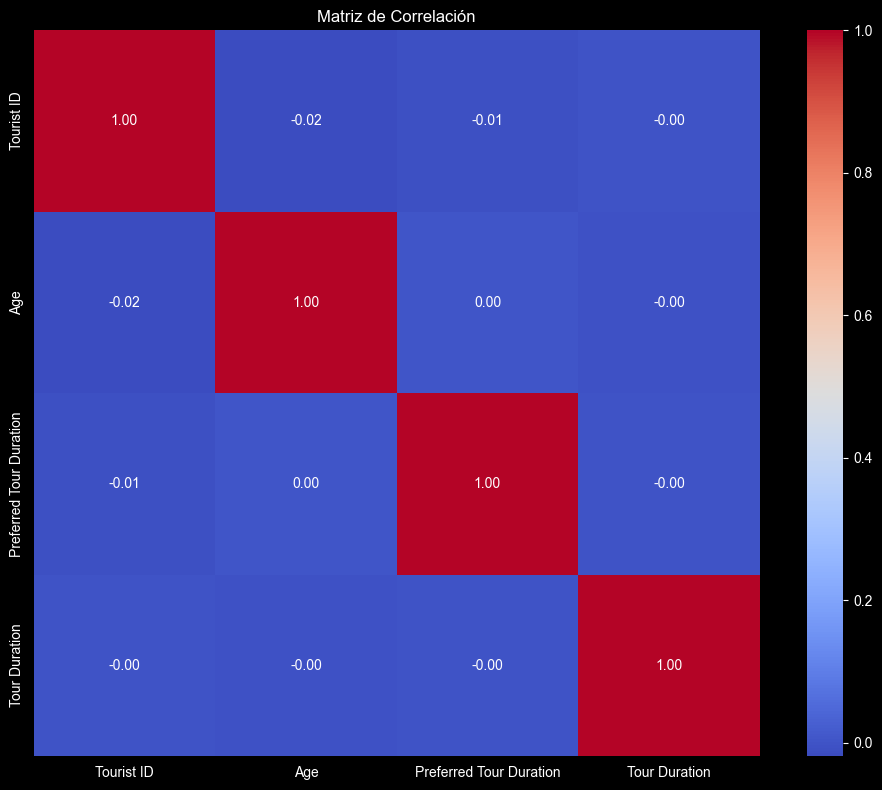

[EDA] Gráfica guardada: outputs/tourism\eda\top_categories.png


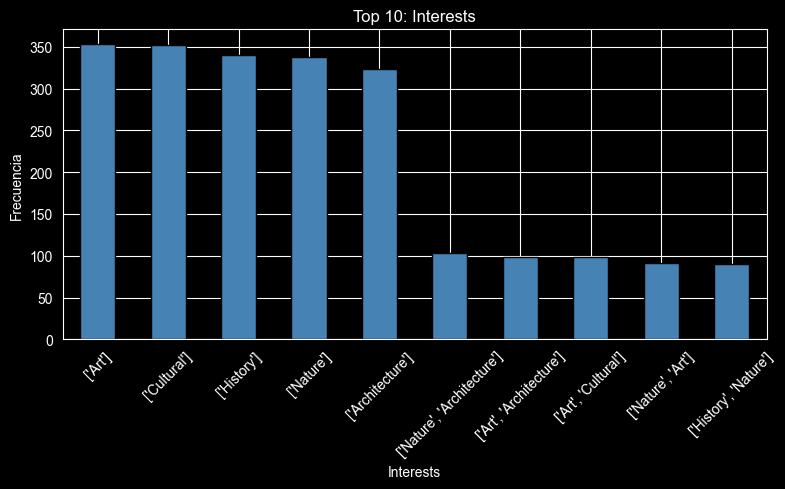


▶▶▶ PASO 3: TRANSFORMACIÓN ◀◀◀
[Transformer] Columna 'Interests' convertida a listas.
[Transformer] Columna 'Sites Visited' convertida a listas.

▶▶▶ PASO 4: MODELOS DE ASOCIACIÓN ◀◀◀

  ── Columna: 'Interests' (5000 transacciones) ──

[Apriori] Ejecutando con soporte=0.1, confianza=0.1 ...
[Apriori] Itemsets frecuentes: 15
[Apriori] Reglas generadas  : 20

--- TOP 10 REGLAS APRIORI ---
   antecedents    consequents  support  confidence     lift
      (Nature)      (History)   0.1364    0.337457 0.863061
     (History)       (Nature)   0.1364    0.348849 0.863061
      (Nature) (Architecture)   0.1350    0.333993 0.848560
(Architecture)       (Nature)   0.1350    0.342988 0.848560
    (Cultural)      (History)   0.1306    0.329965 0.843899
     (History)     (Cultural)   0.1306    0.334015 0.843899
         (Art) (Architecture)   0.1322    0.329840 0.838009
(Architecture)          (Art)   0.1322    0.335874 0.838009
      (Nature)          (Art)   0.1348    0.333498 0.832082
         

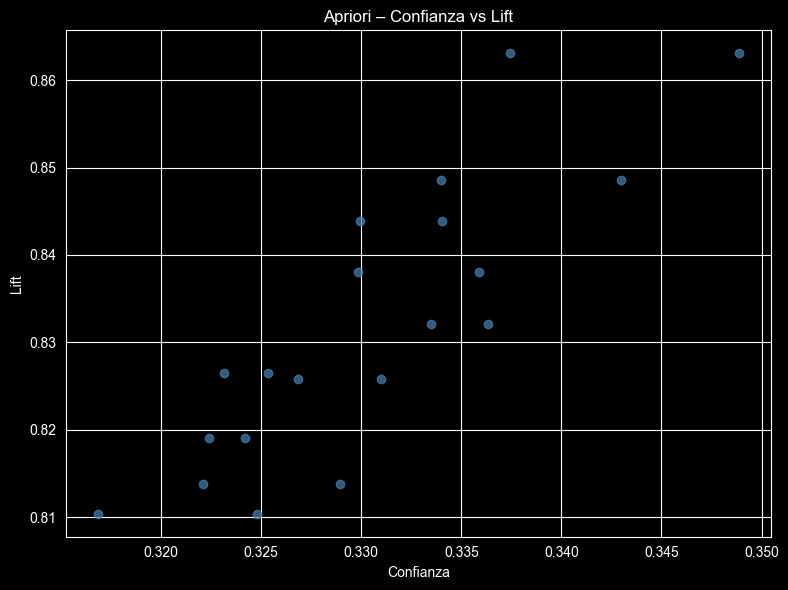

[Apriori] Gráfica guardada: outputs/tourism\Interests\apriori\network_rules.png


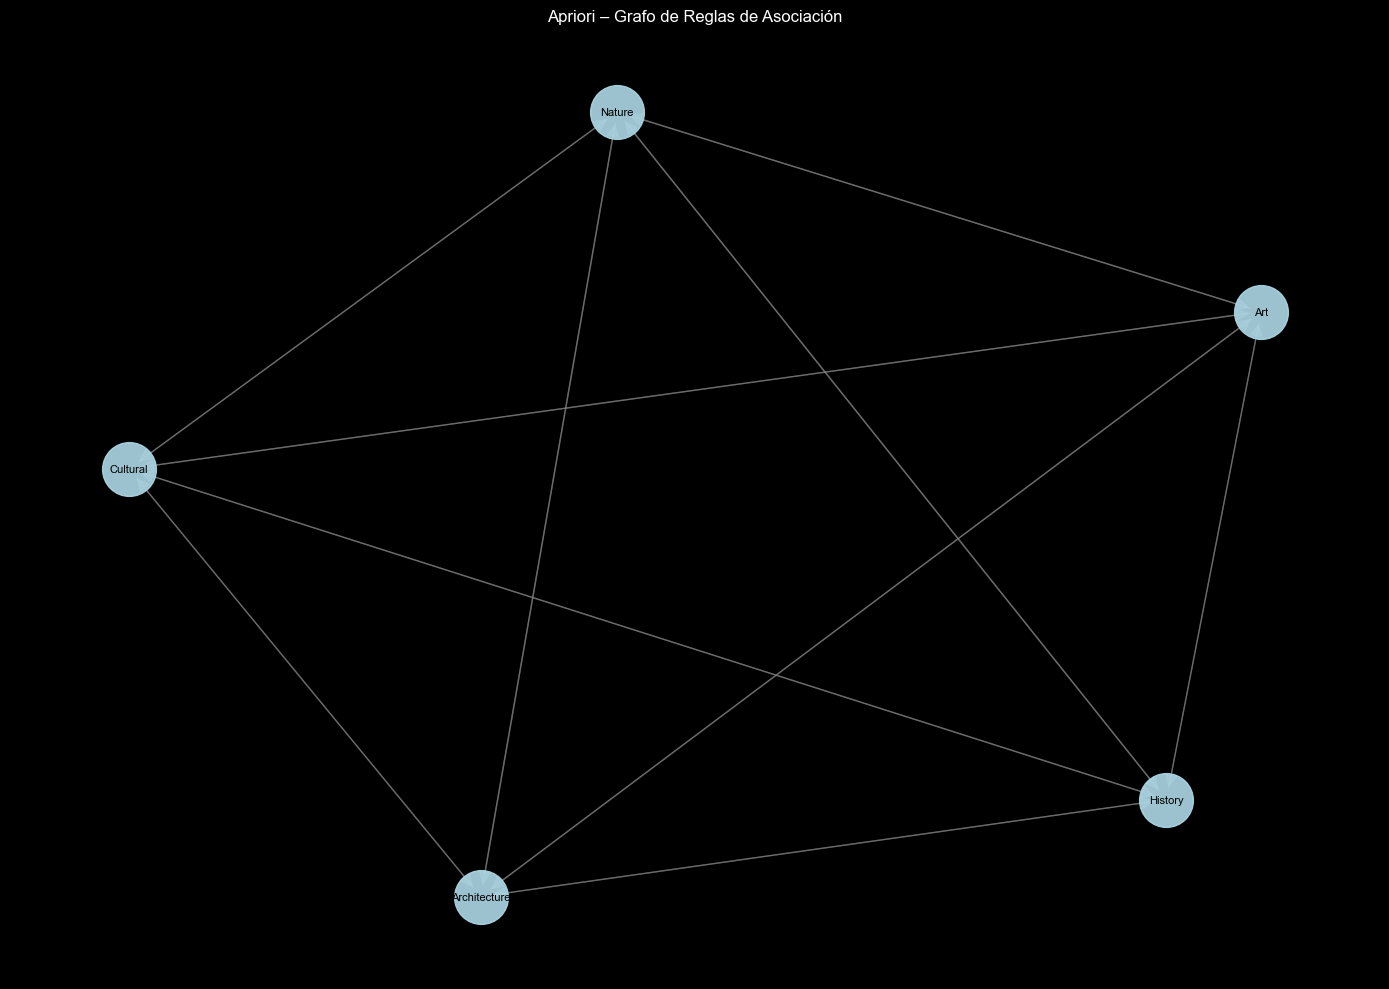


[ECLAT] Ejecutando con soporte=0.1, confianza=0.1 ...
[ECLAT] Itemsets frecuentes: 15
[ECLAT] Reglas generadas  : 20

--- TOP 10 REGLAS ECLAT ---
   antecedents    consequents  support  confidence   lift
     (History)       (Nature)   0.1364      0.3488 0.8631
      (Nature)      (History)   0.1364      0.3375 0.8631
      (Nature) (Architecture)   0.1350      0.3340 0.8486
(Architecture)       (Nature)   0.1350      0.3430 0.8486
     (History)     (Cultural)   0.1306      0.3340 0.8439
    (Cultural)      (History)   0.1306      0.3300 0.8439
(Architecture)          (Art)   0.1322      0.3359 0.8380
         (Art) (Architecture)   0.1322      0.3298 0.8380
         (Art)       (Nature)   0.1348      0.3363 0.8321
      (Nature)          (Art)   0.1348      0.3335 0.8321
[ECLAT] Gráfica guardada: outputs/tourism\Interests\eclat\scatter_confidence_lift.png


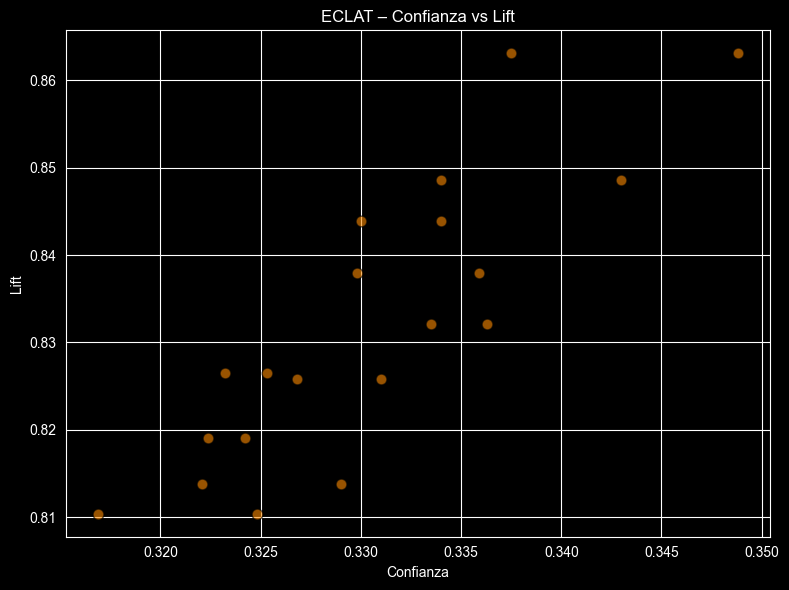

[ECLAT] Gráfica guardada: outputs/tourism\Interests\eclat\network_rules.png


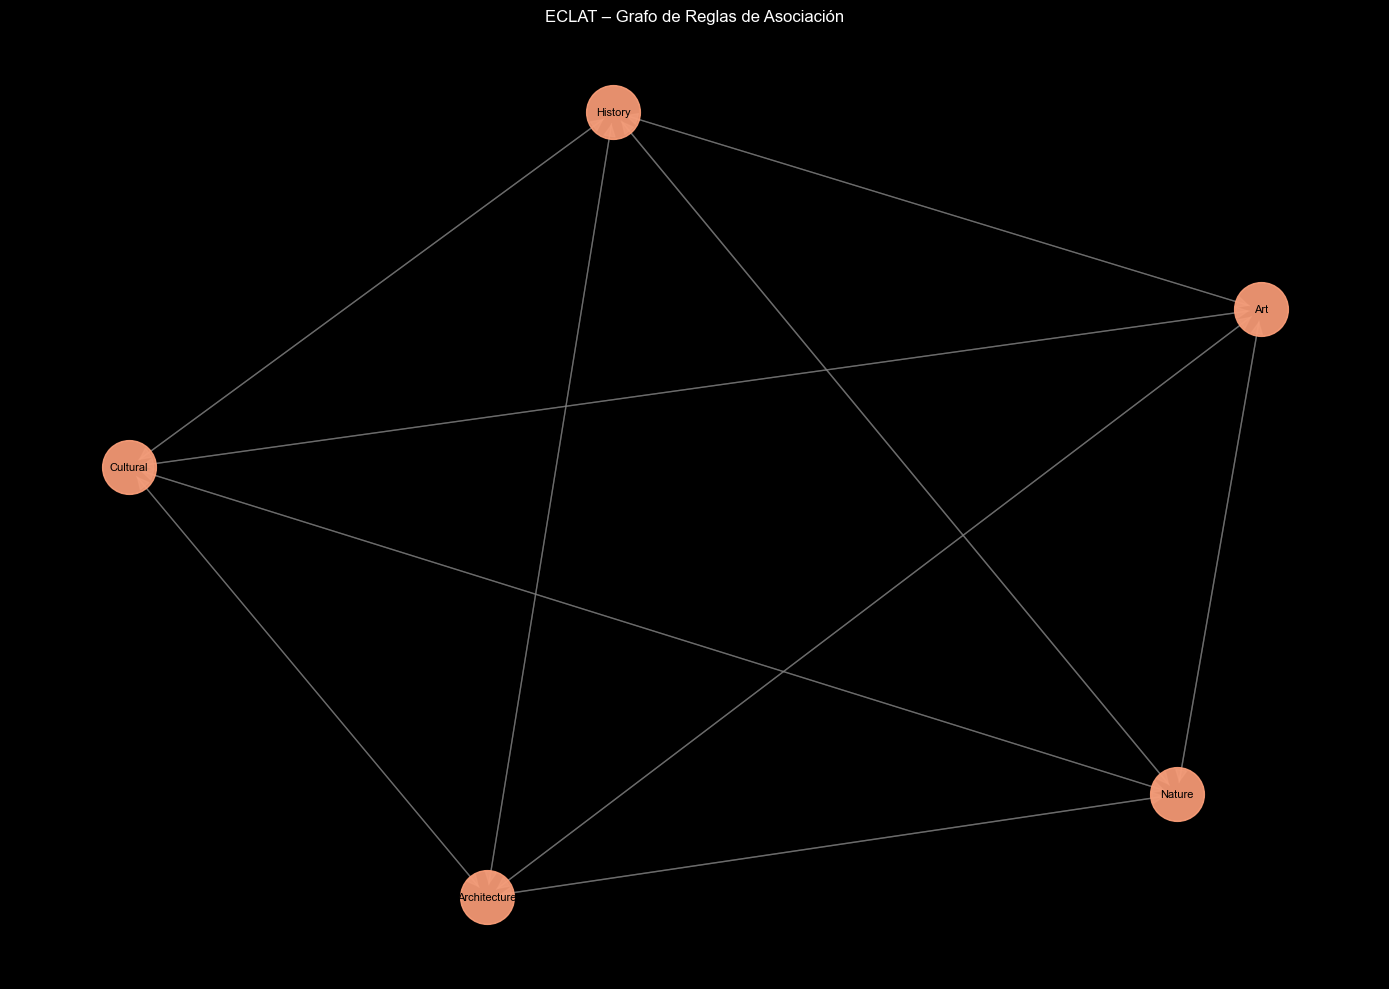


  ── Columna: 'Sites Visited' (5000 transacciones) ──

[Apriori] Ejecutando con soporte=0.1, confianza=0.1 ...
[Apriori] Itemsets frecuentes: 15
[Apriori] Reglas generadas  : 20

--- TOP 10 REGLAS APRIORI ---
          antecedents           consequents  support  confidence     lift
       (Machu Picchu)           (Taj Mahal)   0.1326    0.345312 0.858132
          (Taj Mahal)        (Machu Picchu)   0.1326    0.329523 0.858132
       (Eiffel Tower)           (Colosseum)   0.1392    0.335907 0.842295
          (Colosseum)        (Eiffel Tower)   0.1392    0.349047 0.842295
          (Colosseum)        (Machu Picchu)   0.1288    0.322969 0.841065
       (Machu Picchu)           (Colosseum)   0.1288    0.335417 0.841065
       (Eiffel Tower)        (Machu Picchu)   0.1334    0.321911 0.838310
       (Machu Picchu)        (Eiffel Tower)   0.1334    0.347396 0.838310
(Great Wall of China)           (Colosseum)   0.1324    0.332496 0.833742
          (Colosseum) (Great Wall of China)   0.13

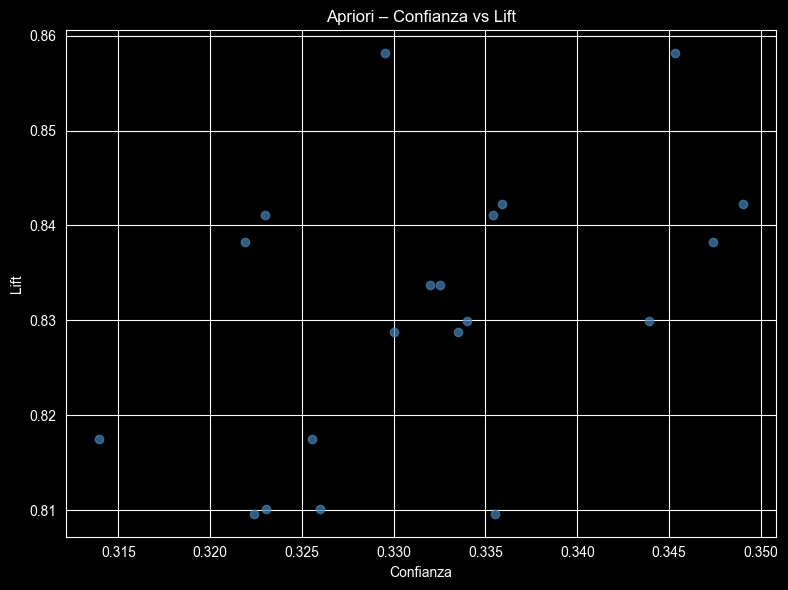

[Apriori] Gráfica guardada: outputs/tourism\Sites_Visited\apriori\network_rules.png


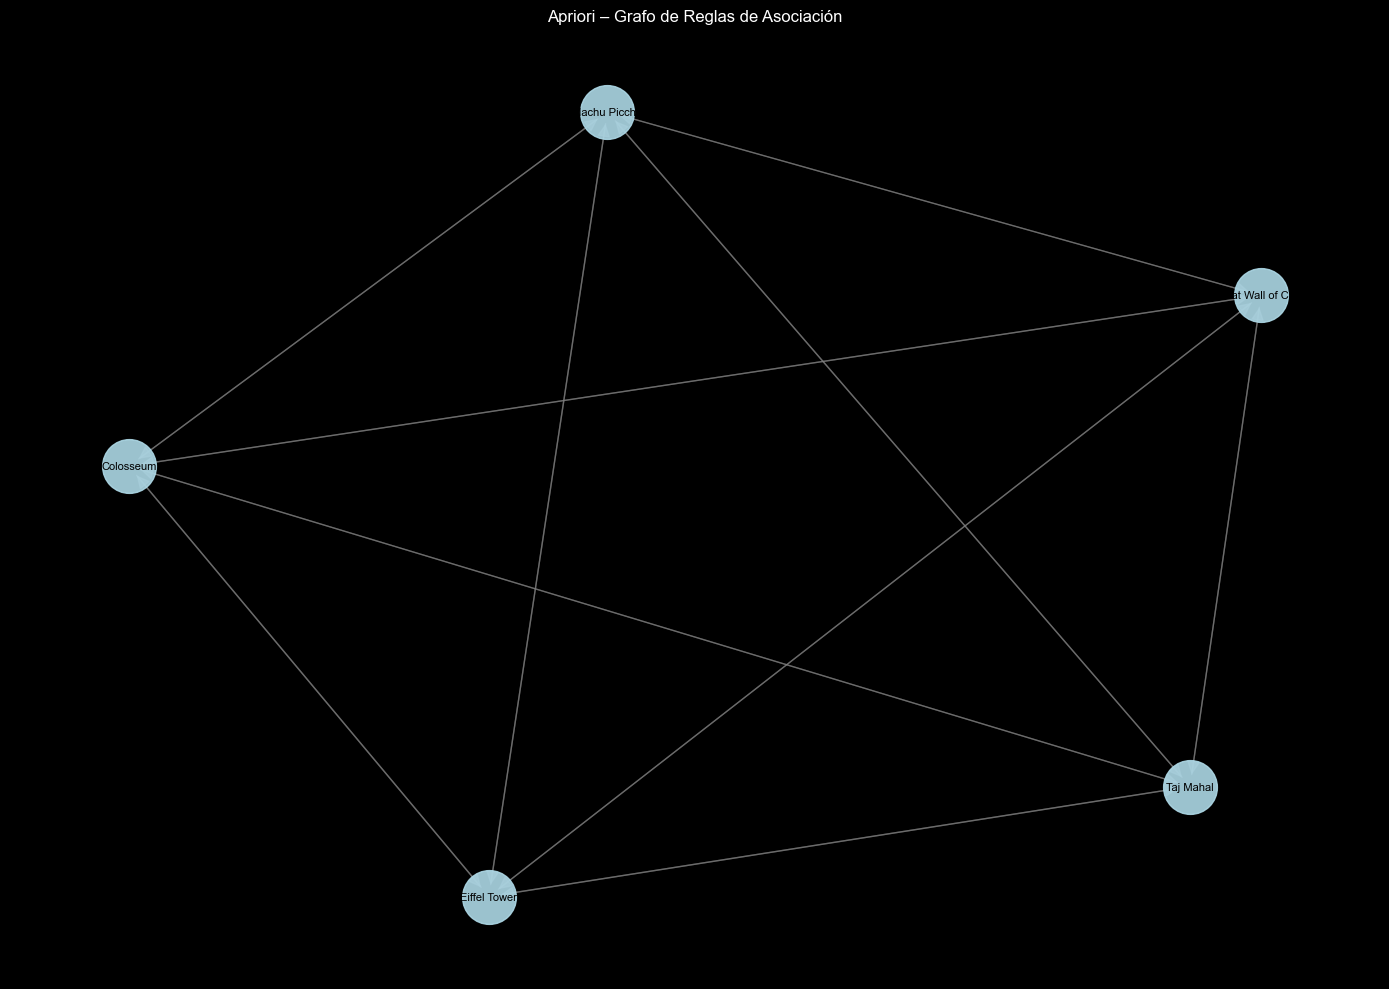


[ECLAT] Ejecutando con soporte=0.1, confianza=0.1 ...
[ECLAT] Itemsets frecuentes: 15
[ECLAT] Reglas generadas  : 20

--- TOP 10 REGLAS ECLAT ---
          antecedents           consequents  support  confidence   lift
          (Taj Mahal)        (Machu Picchu)   0.1326      0.3295 0.8581
       (Machu Picchu)           (Taj Mahal)   0.1326      0.3453 0.8581
          (Colosseum)        (Eiffel Tower)   0.1392      0.3490 0.8423
       (Eiffel Tower)           (Colosseum)   0.1392      0.3359 0.8423
       (Machu Picchu)           (Colosseum)   0.1288      0.3354 0.8411
          (Colosseum)        (Machu Picchu)   0.1288      0.3230 0.8411
       (Machu Picchu)        (Eiffel Tower)   0.1334      0.3474 0.8383
       (Eiffel Tower)        (Machu Picchu)   0.1334      0.3219 0.8383
          (Colosseum) (Great Wall of China)   0.1324      0.3320 0.8337
(Great Wall of China)           (Colosseum)   0.1324      0.3325 0.8337
[ECLAT] Gráfica guardada: outputs/tourism\Sites_Visited\eclat

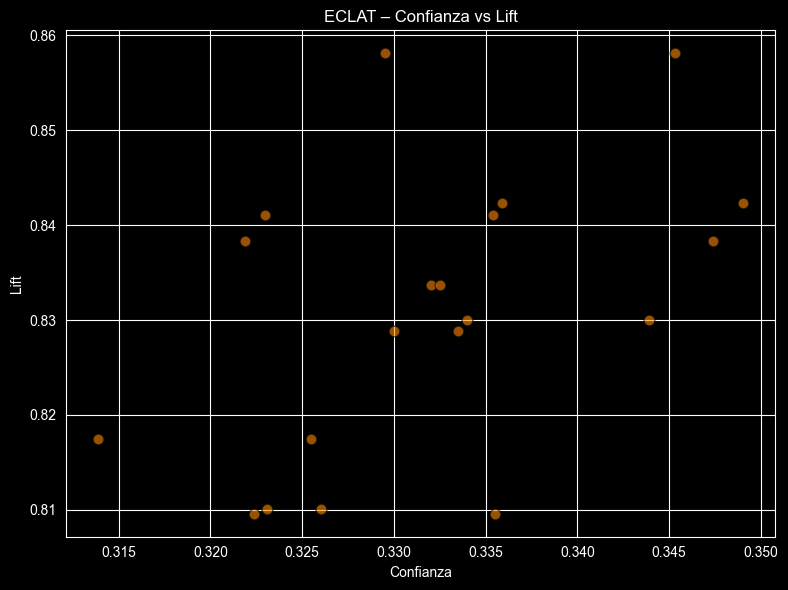

[ECLAT] Gráfica guardada: outputs/tourism\Sites_Visited\eclat\network_rules.png


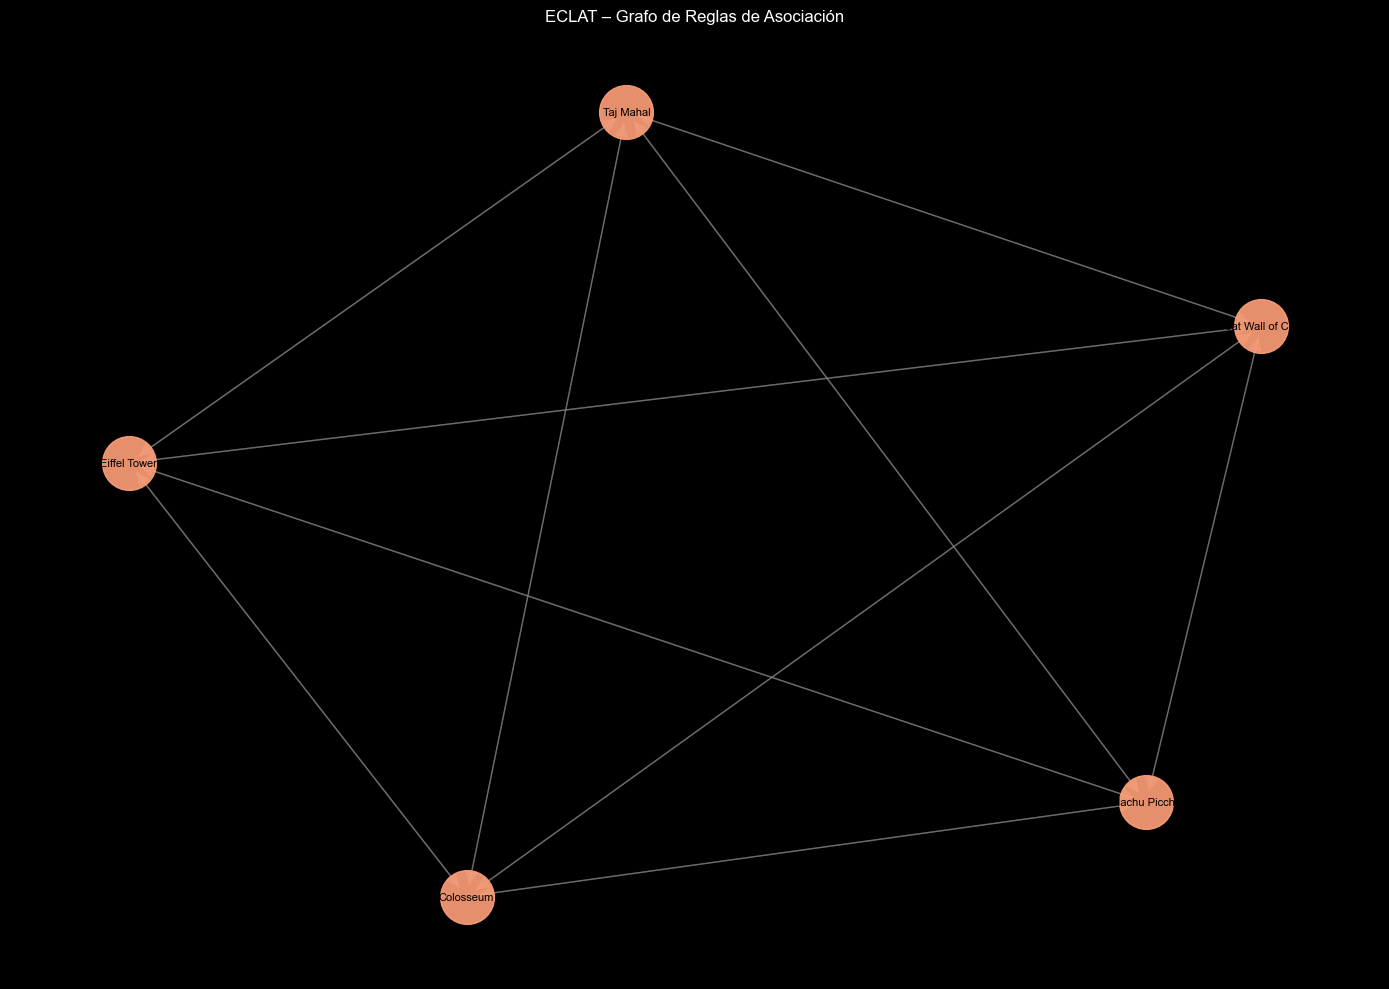


▶▶▶ PASO 5: EXPORTACIÓN DE RESULTADOS ◀◀◀
[Pipeline] Reglas exportadas: outputs/tourism\Interests\rules_apriori.csv
[Pipeline] Reglas exportadas: outputs/tourism\Interests\rules_eclat.csv
[Pipeline] Reglas exportadas: outputs/tourism\Sites_Visited\rules_apriori.csv
[Pipeline] Reglas exportadas: outputs/tourism\Sites_Visited\rules_eclat.csv

  PIPELINE FINALIZADO ✓

Output dir : outputs/tourism
Columnas procesadas: ['Interests', 'Sites Visited']


In [6]:
MIN_SUPPORT    = 0.1   # soporte mínimo
MIN_CONFIDENCE = 0.1   # confianza mínima

print(f'Soporte mínimo    : {MIN_SUPPORT}')
print(f'Confianza mínima  : {MIN_CONFIDENCE}')

pp_tourism = Pipeline(
    df=df_tourism,
    min_support=MIN_SUPPORT,
    min_confidence=MIN_CONFIDENCE,
)

results_tourism, output_dir_tourism = pp_tourism.execute('tourism')

print(f'\nOutput dir : {output_dir_tourism}')
print(f'Columnas procesadas: {list(results_tourism.keys())}')